## 0. Install Dependencies

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "scikit-learn", "pandas", "numpy", "matplotlib", "scipy", "tabulate"])

0

## 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from tabulate import tabulate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, matthews_corrcoef

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

# ── Seed Range ────────────────────────────────────────────────────────────────
SEEDS         = list(range(2026, 2056))   # 30 seeds: 2026–2055 inclusive
N_RUNS        = len(SEEDS)

# ── C grid for LogisticRegression CV ─────────────────────────────────────────
# LogisticRegression uses C = 1/alpha (inverse regularisation strength).
# Higher C = less regularisation. Previous RidgeClassifier consistently
# selected alpha=100 (very high regularisation), which over-suppressed the
# LLM coefficient. This refined grid adds resolution at the high end and
# covers a wider range to let CV find the true optimum.
# NOTE: We tune C directly (not alpha) to stay native to LogisticRegression.
CV_FOLDS      = 5
C_GRID        = [0.00001, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5,
                 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]

ECE_BINS      = 10
ECE_IMPLEMENTATION_VERSION = "positive_class_ece_v2_2026-07-26"
P_ALPHA       = 0.05   # significance threshold

# ── Column names ──────────────────────────────────────────────────────────────
ENCODER_COLS  = ["indobert-p1", "indobertweet", "mdeberta-v3"]
LLM_COL       = "gemini-3-flash-preview"
FEATURE_NAMES = ENCODER_COLS + [LLM_COL]
LABEL_COL     = "label"

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/Final Thesis Execution")
OUT_DIR       = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/Final Thesis Execution/Phase C Results/Ablation and Error/ECE Positive Class V2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Per-seed file templates (format with seed integer)
OOF_TRAIN_TEMPLATE  = str(PROJECT_ROOT / "oof_results" / "oof_train_{seed}.csv")
PROBS_TEST_TEMPLATE = str(PROJECT_ROOT / "oof_results" / "probs_test_{seed}.csv")

# Static files loaded ONCE outside the loop
LLM_TRAIN_NPY   = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/LLM Zero-Shot Results/npy preds/llm_train_preds.npy")
LLM_RAND_NPY    = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/LLM Zero-Shot Results/npy preds/llm_rand_preds.npy")
LLM_TEST_NPY    = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/LLM Zero-Shot Results/npy preds/llm_test_preds.npy")
TEST_LABELS_CSV  = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/dataset/datd_test.csv")
TRAIN_LABELS_CSV = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/dataset/datd_train.csv")
RAND_LABELS_CSV  = Path(r"C:/Users/KOMPUTER/VSCode Projects/IndoEnsemble/dataset/datd_rand_cleaned.csv")

logger.info("Seeds  : %d–%d (%d runs)", SEEDS[0], SEEDS[-1], N_RUNS)
logger.info("OutDir : %s", OUT_DIR)
logger.info("ECE    : %s (%d equal-width bins)", ECE_IMPLEMENTATION_VERSION, ECE_BINS)

18:14:03 [INFO] Seeds  : 2026–2055 (30 runs)
18:14:03 [INFO] OutDir : C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2
18:14:03 [INFO] ECE    : positive_class_ece_v2_2026-07-26 (10 equal-width bins)


## 2. Shared Utility Functions

In [3]:
# Remove the old generic ECE symbol if this notebook is run in a kernel that
# previously executed the inconsistent implementation. compute_metrics below
# references the explicit positive-class function, so stale state cannot be used.
globals().pop("expected_calibration_error", None)


def expected_calibration_error_positive_class(
    y_true: np.ndarray,
    y_prob_pos: np.ndarray,
    n_bins: int = ECE_BINS,
) -> float:
    r"""
    Positive-class Expected Calibration Error for binary classification.

    Samples are binned using P(y=1). Within each bin, the function compares:
      - mean predicted P(y=1), and
      - observed proportion of class 1.

    ECE = sum_b (|B_b| / N) * |mean(y in B_b) - mean(P(y=1) in B_b)|
    """
    y_true = np.asarray(y_true, dtype=np.int32).ravel()
    y_prob_pos = np.asarray(y_prob_pos, dtype=float).ravel()

    if y_true.shape != y_prob_pos.shape:
        raise ValueError(
            f"ECE shape mismatch: y_true={y_true.shape}, "
            f"y_prob_pos={y_prob_pos.shape}"
        )
    if y_true.size == 0:
        raise ValueError("ECE cannot be calculated on an empty array.")
    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(f"y_true must be binary; found {np.unique(y_true)}")
    if not np.all(np.isfinite(y_prob_pos)):
        raise ValueError("y_prob_pos contains NaN or infinite values.")
    if not np.all((0.0 <= y_prob_pos) & (y_prob_pos <= 1.0)):
        raise ValueError("y_prob_pos must contain probabilities in [0, 1].")
    if not isinstance(n_bins, (int, np.integer)) or n_bins < 2:
        raise ValueError("n_bins must be an integer >= 2.")

    bin_edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0

    for bin_index, (low, high) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if bin_index == len(bin_edges) - 2:
            mask = (y_prob_pos >= low) & (y_prob_pos <= high)
        else:
            mask = (y_prob_pos >= low) & (y_prob_pos < high)

        if not np.any(mask):
            continue

        mean_probability = float(y_prob_pos[mask].mean())
        observed_positive_rate = float(y_true[mask].mean())
        bin_weight = float(mask.mean())
        ece += bin_weight * abs(observed_positive_rate - mean_probability)

    return float(ece)


def expected_calibration_error_predicted_class(
    y_true: np.ndarray,
    y_prob_pos: np.ndarray,
    n_bins: int = ECE_BINS,
) -> float:
    r"""
    Optional predicted-class ECE for diagnostic use only.

    Samples are binned by max(P(y=1), P(y=0)); mean predicted-class
    confidence is compared with fraction correct. This definition is kept
    separate and is not used in the thesis summary table.
    """
    y_true = np.asarray(y_true, dtype=np.int32).ravel()
    y_prob_pos = np.asarray(y_prob_pos, dtype=float).ravel()

    if y_true.shape != y_prob_pos.shape:
        raise ValueError(
            f"ECE shape mismatch: y_true={y_true.shape}, "
            f"y_prob_pos={y_prob_pos.shape}"
        )
    if not np.all((0.0 <= y_prob_pos) & (y_prob_pos <= 1.0)):
        raise ValueError("y_prob_pos must contain probabilities in [0, 1].")

    y_pred = (y_prob_pos >= 0.5).astype(np.int32)
    confidence = np.maximum(y_prob_pos, 1.0 - y_prob_pos)
    correct = (y_pred == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0

    for bin_index, (low, high) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if bin_index == len(bin_edges) - 2:
            mask = (confidence >= low) & (confidence <= high)
        else:
            mask = (confidence >= low) & (confidence < high)

        if not np.any(mask):
            continue

        ece += float(mask.mean()) * abs(
            float(correct[mask].mean()) - float(confidence[mask].mean())
        )

    return float(ece)


def compute_metrics(y_true, y_pred, y_prob_pos) -> dict:
    """Return Macro F1, MCC, and positive-class ECE."""
    y_true = np.asarray(y_true, dtype=np.int32).ravel()
    y_pred = np.asarray(y_pred, dtype=np.int32).ravel()
    y_prob_pos = np.asarray(y_prob_pos, dtype=float).ravel()

    if not (y_true.shape == y_pred.shape == y_prob_pos.shape):
        raise ValueError(
            f"compute_metrics shape mismatch: y_true={y_true.shape}, "
            f"y_pred={y_pred.shape}, y_prob_pos={y_prob_pos.shape}"
        )

    return {
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "ece": expected_calibration_error_positive_class(
            y_true=y_true,
            y_prob_pos=y_prob_pos,
            n_bins=ECE_BINS,
        ),
    }


def assert_positive_class_ece_runtime() -> None:
    """Fail immediately if the corrected ECE implementation is not active."""
    referenced_names = set(compute_metrics.__code__.co_names)
    required_name = "expected_calibration_error_positive_class"

    if required_name not in referenced_names:
        raise RuntimeError(
            "compute_metrics is not using positive-class ECE. Restart the "
            "kernel/session and run this notebook from the first cell."
        )
    if "expected_calibration_error" in referenced_names:
        raise RuntimeError(
            "The old generic ECE function is still referenced by compute_metrics."
        )

    # Perfectly calibrated synthetic example:
    # 10% positives and P(y=1)=0.10 for every sample must yield ECE ~= 0.
    y_sanity = np.array([0] * 90 + [1] * 10, dtype=np.int32)
    p_sanity = np.full(100, 0.10, dtype=float)
    ece_sanity = expected_calibration_error_positive_class(
        y_sanity, p_sanity, n_bins=10
    )

    if not np.isclose(ece_sanity, 0.0, atol=1e-12):
        raise RuntimeError(
            f"Positive-class ECE sanity test failed: ECE={ece_sanity}"
        )

    print("ECE PREFLIGHT PASSED")
    print("  Implementation :", ECE_IMPLEMENTATION_VERSION)
    print("  Definition     : bins by P(y=1); compares observed positive rate")
    print("  Sanity ECE     :", ece_sanity)
    print("  compute_metrics references:", compute_metrics.__code__.co_names)


assert_positive_class_ece_runtime()

def tune_C(
    X: np.ndarray,
    y: np.ndarray,
    c_values: list = C_GRID,
    cv: int = CV_FOLDS,
    seed: int = 42,
) -> float:
    """
    Grid-search the best LogisticRegression C via stratified k-fold CV (macro-F1).
    C = 1/regularisation_strength. Larger C = less regularisation.
    Returns the best C value.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    y   = np.asarray(y).ravel().astype(np.int32)
    best_C, best_score = c_values[0], -np.inf
    for C in c_values:
        clf   = LogisticRegression(C=C, max_iter=1000, random_state=seed, solver="lbfgs")
        score = cross_val_score(clf, X, y, cv=skf, scoring="f1_macro").mean()
        if score > best_score:
            best_score, best_C = score, C
    return best_C


def fit_predict_logistic(X_train, y_train, X_test, C, seed):
    """
    Fit a LogisticRegression meta-learner, return (hard_preds, probs, coef).

    Advantages over RidgeClassifier:
      - Directly optimises log-loss (classification objective, not MSE)
      - predict_proba() provides class probabilities; calibration must still be evaluated separately
      - C parameter is interpretable: C=1/alpha, so smaller C = more regularisation

    StandardScaler is fit on X_train and applied to X_test — no leakage.
    """
    y_train_bin = np.asarray(y_train).ravel().astype(np.int32)
    assert set(np.unique(y_train_bin)).issubset({0, 1}), \
        f"y_train contains non-binary labels: {np.unique(y_train_bin)}"

    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_train)
    Xte    = scaler.transform(X_test)

    clf    = LogisticRegression(C=C, max_iter=1000, random_state=seed, solver="lbfgs")
    clf.fit(Xtr, y_train_bin)

    # predict_proba returns (N, 2) — column 1 is P(class=1)
    probs  = clf.predict_proba(Xte)[:, 1].ravel()
    preds  = clf.predict(Xte).ravel()
    coef   = clf.coef_.ravel()[:X_train.shape[1]]
    return preds, probs, coef


logger.info("Utility functions ready — meta-learner: LogisticRegression (L2).")

18:14:03 [INFO] Utility functions ready — meta-learner: LogisticRegression (L2).


ECE PREFLIGHT PASSED
  Implementation : positive_class_ece_v2_2026-07-26
  Definition     : bins by P(y=1); compares observed positive rate
  Sanity ECE     : 2.7755575615628914e-17
  compute_metrics references: ('np', 'asarray', 'int32', 'ravel', 'float', 'shape', 'ValueError', 'f1_score', 'matthews_corrcoef', 'expected_calibration_error_positive_class', 'ECE_BINS')


## 3. Load Static Data (Once, Outside the Loop)

> **Design note:** All LLM arrays are Phase B outputs that never change across seeds.
> They are loaded once here to avoid redundant I/O.
> `llm_train_preds.npy` and `llm_rand_preds.npy` are concatenated into a single
> training array that aligns with the combined OOF encoder pool.
> `llm_test_preds.npy` is kept separate and used only for evaluation.

In [4]:
# ── Inspect columns first to catch naming mismatches early ───────────────────
_test_df_check = pd.read_csv(TEST_LABELS_CSV)
print("datd_test.csv columns :", _test_df_check.columns.tolist())
print("datd_test.csv shape   :", _test_df_check.shape)

# ── UPDATE LABEL_COL HERE if the printed column name differs from 'label' ─────
LABEL_COL = "label"   # ← adjust to match the actual column name printed above

# Ground-truth test labels — identical across all 30 runs
y_test = _test_df_check[LABEL_COL].dropna().values.astype(np.int32)
logger.info("y_test shape : %s  (pos=%.1f%%)", y_test.shape, 100 * y_test.mean())

# Training labels: concatenate datd_train + datd_rand.
# datd_rand.csv has already been cleaned (2 NaN rows removed),
# so the combined pool is exactly 9181 rows — matching the OOF files.
_train_df = pd.read_csv(TRAIN_LABELS_CSV)[[LABEL_COL]].dropna().reset_index(drop=True)
_rand_df  = pd.read_csv(RAND_LABELS_CSV )[[LABEL_COL]].dropna().reset_index(drop=True)
y_train_full = np.concatenate([
    _train_df[LABEL_COL].values.astype(np.int32),
    _rand_df[LABEL_COL].values.astype(np.int32),
])
logger.info("y_train (train) : %d rows", len(_train_df))
logger.info("y_train (rand)  : %d rows", len(_rand_df))
logger.info("y_train combined: %d rows (pos=%.1f%%)",
            len(y_train_full), 100 * y_train_full.mean())

# ── LLM training array: concatenate train + rand ──────────────────────────────
llm_train_part = np.load(LLM_TRAIN_NPY).astype(np.float32)
llm_rand_part  = np.load(LLM_RAND_NPY ).astype(np.float32)
llm_train_full = np.concatenate([llm_train_part, llm_rand_part], axis=0)

# ── LLM test array: unchanged ─────────────────────────────────────────────────
llm_test_flat  = np.load(LLM_TEST_NPY).astype(np.float32)   # (550,)

logger.info("LLM train part  : %s", llm_train_part.shape)
logger.info("LLM rand  part  : %s", llm_rand_part.shape)
logger.info("LLM train+rand  : %s  (combined)", llm_train_full.shape)
logger.info("LLM test        : %s", llm_test_flat.shape)

# All three training arrays must agree on row count before the loop starts
assert llm_train_full.shape[0] == y_train_full.shape[0], \
    f"LLM train rows ({llm_train_full.shape[0]}) != label rows ({y_train_full.shape[0]})"
assert llm_test_flat.shape[0] == y_test.shape[0], \
    f"LLM test rows ({llm_test_flat.shape[0]}) != y_test rows ({y_test.shape[0]})"

# ── Validate that llm_test_flat is prob(class=1), not raw confidence ───────────
# Phase B summary (phase_b_summary.json) reports F1=0.8024, MCC=0.6122.
# If .npy files store raw confidence (not prob_class1), thresholding at 0.5
# produces near-zero MCC because a class-0 prediction with confidence 0.85
# gets misread as 85%% probability of class 1.
# Fix: re-run Phase B cells 6 onwards — saving logic now stores
# np.where(preds==1, conf, 1-conf) instead of raw confidence.
EXPECTED_MCC  = 0.612244   # from phase_b_summary.json
_llm_pred_chk = (llm_test_flat >= 0.5).astype(np.int32)
_llm_mcc_chk  = float(matthews_corrcoef(y_test, _llm_pred_chk))
if abs(_llm_mcc_chk - EXPECTED_MCC) > 0.05:
    raise ValueError(
        f"llm_test_preds.npy validation FAILED (MCC={_llm_mcc_chk:.4f}, expected ~{EXPECTED_MCC}).\n"
        "The .npy files store raw confidence, not prob(class=1).\n"
        "Re-run Phase B cells 6 onwards — the save logic is now corrected."
    )
logger.info("LLM .npy validation PASSED: MCC=%.4f", _llm_mcc_chk)

# ── Pure LLM baseline (static — compute once) ─────────────────────────────────
llm_pred_test = _llm_pred_chk
llm_metrics   = compute_metrics(y_test, llm_pred_test, llm_test_flat)
logger.info("Pure LLM  F1=%.4f  MCC=%.4f  ECE=%.4f",
            llm_metrics["macro_f1"], llm_metrics["mcc"], llm_metrics["ece"])

18:14:03 [INFO] y_test shape : (550,)  (pos=29.3%)
18:14:03 [INFO] y_train (train) : 2201 rows
18:14:03 [INFO] y_train (rand)  : 6980 rows
18:14:03 [INFO] y_train combined: 9181 rows (pos=16.0%)
18:14:03 [INFO] LLM train part  : (2201,)
18:14:03 [INFO] LLM rand  part  : (6980,)
18:14:03 [INFO] LLM train+rand  : (9181,)  (combined)
18:14:03 [INFO] LLM test        : (550,)
18:14:03 [INFO] LLM .npy validation PASSED: MCC=0.6091
18:14:03 [INFO] Pure LLM  F1=0.8007  MCC=0.6091  ECE=0.1043


datd_test.csv columns : ['text', 'label']
datd_test.csv shape   : (550, 2)


## 4. The 30-Seed Loop

In [5]:
# Mandatory guard: prevents the 30-seed experiment from running with the old ECE.
assert_positive_class_ece_runtime()
print(f"Writing fresh outputs to: {OUT_DIR}")

# Storage — one dict per seed, keyed by config name
records = []          # list of dicts — one per seed, all configs
coef_store = []       # Ridge coefficients (4,) per seed — for boxplot

# For reliability diagrams we only keep the last seed's outputs
last_seed_data = {}

logger.info("Starting 30-seed loop...")

for i_seed, seed in enumerate(SEEDS):
    # ── 1. Load per-seed CSVs ─────────────────────────────────────────────────
    oof_path  = Path(OOF_TRAIN_TEMPLATE.format(seed=seed))
    test_path = Path(PROBS_TEST_TEMPLATE.format(seed=seed))

    oof_df   = pd.read_csv(oof_path)
    test_df  = pd.read_csv(test_path)

    # ── 2. Extract encoder arrays ─────────────────────────────────────────────
    enc_train = oof_df[ENCODER_COLS].values.astype(np.float32)    # (9181, 3)
    enc_test  = test_df[ENCODER_COLS].values.astype(np.float32)   # (550,  3)

    # ── 3. Size assertions — must all agree before any computation ─────────────
    assert enc_train.shape[0] == llm_train_full.shape[0] == y_train_full.shape[0], \
        f"[Seed {seed}] Train size mismatch: enc={enc_train.shape[0]}, " \
        f"llm={llm_train_full.shape[0]}, y={y_train_full.shape[0]}"
    assert enc_test.shape[0] == llm_test_flat.shape[0] == y_test.shape[0], \
        f"[Seed {seed}] Test size mismatch."

    # ── 4. Build feature matrices ─────────────────────────────────────────────
    llm_col_train = llm_train_full.reshape(-1, 1)   # (9181, 1)
    llm_col_test  = llm_test_flat.reshape(-1, 1)    # (550,  1)

    X_train_homo = enc_train                                         # (9181, 3)
    X_train_asym = np.hstack([enc_train, llm_col_train])             # (9181, 4)
    X_test_homo  = enc_test                                          # (550,  3)
    X_test_asym  = np.hstack([enc_test,  llm_col_test])              # (550,  4)

    # ── 5. C tuning (per-seed, inside the loop — correct) ─────────────────────
    best_C_homo = tune_C(X_train_homo, y_train_full, seed=seed)
    best_C_asym = tune_C(X_train_asym, y_train_full, seed=seed)

    # ── 6. Fit & predict — Homogeneous ────────────────────────────────────────
    pred_homo, conf_homo, _ = fit_predict_logistic(
        X_train_homo, y_train_full, X_test_homo, best_C_homo, seed
    )

    # ── 7. Fit & predict — Asymmetric ─────────────────────────────────────────
    pred_asym, conf_asym, coef_asym = fit_predict_logistic(
        X_train_asym, y_train_full, X_test_asym, best_C_asym, seed
    )
    coef_store.append(coef_asym)   # (4,) — for boxplot

    # ── 9. Best Single Encoder (oracle — highest MCC among 3 encoders) ────────
    # ⚠ THESIS NOTE: This picks the best encoder *per seed on the test set*.
    # It is an oracle/upper-bound, NOT a deployable model, because you cannot
    # know which encoder is best without observing test labels.
    best_enc_metrics = None
    best_enc_name    = None
    for enc_col in ENCODER_COLS:
        col_conf = test_df[enc_col].values.astype(np.float32)
        col_pred = (col_conf >= 0.5).astype(np.int32)
        m        = compute_metrics(y_test, col_pred, col_conf)
        if best_enc_metrics is None or m["mcc"] > best_enc_metrics["mcc"]:
            best_enc_metrics = m
            best_enc_name    = enc_col

    # ── 10. Compute metrics once per config, then unpack ──────────────────────
    m_homo = compute_metrics(y_test, pred_homo, conf_homo)
    m_asym = compute_metrics(y_test, pred_asym, conf_asym)

    records.append({
        "seed":          seed,
        "best_enc_name": best_enc_name,
        # Best Single Encoder (oracle)
        "enc_macro_f1":  best_enc_metrics["macro_f1"],
        "enc_mcc":       best_enc_metrics["mcc"],
        "enc_ece":       best_enc_metrics["ece"],
        # Homogeneous Stacking
        "homo_macro_f1": m_homo["macro_f1"],
        "homo_mcc":      m_homo["mcc"],
        "homo_ece":      m_homo["ece"],
        # Asymmetric Stacking
        "asym_macro_f1": m_asym["macro_f1"],
        "asym_mcc":      m_asym["mcc"],
        "asym_ece":      m_asym["ece"],
        "alpha_homo":    best_C_homo,
        "alpha_asym":    best_C_asym,
    })


    # Print per-seed ECE
    print(f"Seed {seed:4d} | ECE: enc={best_enc_metrics['ece']:.4f}  "
          f"llm={llm_metrics['ece']:.4f}  "
          f"homo={m_homo['ece']:.4f}  asym={m_asym['ece']:.4f}")
    # Keep last seed's data for reliability diagrams
    if seed == SEEDS[-1]:
        last_seed_data = {
            "best_enc_conf": test_df[best_enc_name].values.astype(np.float32),
            "best_enc_pred": (test_df[best_enc_name].values >= 0.5).astype(np.int32),
            "best_enc_name": best_enc_name,
            "asym_conf":     conf_asym,
            "asym_pred":     pred_asym,
        }

    completed = i_seed + 1
    if completed % 10 == 0 or completed == N_RUNS:
        logger.info("Completed %d/%d seeds", completed, N_RUNS)

logger.info("30-seed loop complete.")

18:14:03 [INFO] Starting 30-seed loop...


ECE PREFLIGHT PASSED
  Implementation : positive_class_ece_v2_2026-07-26
  Definition     : bins by P(y=1); compares observed positive rate
  Sanity ECE     : 2.7755575615628914e-17
  compute_metrics references: ('np', 'asarray', 'int32', 'ravel', 'float', 'shape', 'ValueError', 'f1_score', 'matthews_corrcoef', 'expected_calibration_error_positive_class', 'ECE_BINS')
Writing fresh outputs to: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2
Seed 2026 | ECE: enc=0.0917  llm=0.1043  homo=0.0538  asym=0.0610
Seed 2027 | ECE: enc=0.1033  llm=0.1043  homo=0.0442  asym=0.0496
Seed 2028 | ECE: enc=0.0910  llm=0.1043  homo=0.0676  asym=0.0633
Seed 2029 | ECE: enc=0.0985  llm=0.1043  homo=0.0482  asym=0.0507
Seed 2030 | ECE: enc=0.1145  llm=0.1043  homo=0.0571  asym=0.0559
Seed 2031 | ECE: enc=0.0844  llm=0.1043  homo=0.0528  asym=0.0537
Seed 2032 | ECE: enc=0.0901  llm=0.1043  homo=0.0634  asym=0.0554
Seed 2033 | ECE

18:14:09 [INFO] Completed 10/30 seeds


Seed 2035 | ECE: enc=0.1444  llm=0.1043  homo=0.0518  asym=0.0503
Seed 2036 | ECE: enc=0.0896  llm=0.1043  homo=0.0522  asym=0.0537
Seed 2037 | ECE: enc=0.1068  llm=0.1043  homo=0.0634  asym=0.0479
Seed 2038 | ECE: enc=0.1057  llm=0.1043  homo=0.0433  asym=0.0448
Seed 2039 | ECE: enc=0.0965  llm=0.1043  homo=0.0589  asym=0.0598
Seed 2040 | ECE: enc=0.1103  llm=0.1043  homo=0.0519  asym=0.0567
Seed 2041 | ECE: enc=0.1128  llm=0.1043  homo=0.0543  asym=0.0613
Seed 2042 | ECE: enc=0.1127  llm=0.1043  homo=0.0519  asym=0.0551
Seed 2043 | ECE: enc=0.0951  llm=0.1043  homo=0.0569  asym=0.0546
Seed 2044 | ECE: enc=0.0862  llm=0.1043  homo=0.0536  asym=0.0559


18:14:16 [INFO] Completed 20/30 seeds


Seed 2045 | ECE: enc=0.1106  llm=0.1043  homo=0.0454  asym=0.0538
Seed 2046 | ECE: enc=0.1302  llm=0.1043  homo=0.0600  asym=0.0650
Seed 2047 | ECE: enc=0.0922  llm=0.1043  homo=0.0558  asym=0.0544
Seed 2048 | ECE: enc=0.0697  llm=0.1043  homo=0.0427  asym=0.0492
Seed 2049 | ECE: enc=0.0729  llm=0.1043  homo=0.0472  asym=0.0524
Seed 2050 | ECE: enc=0.1322  llm=0.1043  homo=0.0593  asym=0.0506
Seed 2051 | ECE: enc=0.0915  llm=0.1043  homo=0.0586  asym=0.0423
Seed 2052 | ECE: enc=0.0962  llm=0.1043  homo=0.0530  asym=0.0589
Seed 2053 | ECE: enc=0.1102  llm=0.1043  homo=0.0451  asym=0.0577
Seed 2054 | ECE: enc=0.0833  llm=0.1043  homo=0.0527  asym=0.0505


18:14:23 [INFO] Completed 30/30 seeds
18:14:23 [INFO] 30-seed loop complete.


Seed 2055 | ECE: enc=0.1147  llm=0.1043  homo=0.0548  asym=0.0457


## 5. Aggregate Results

In [6]:
df = pd.DataFrame(records)
df.to_csv(OUT_DIR / "phase_c_raw_results.csv", index=False)

def agg(col_prefix):
    """Return mean ± std dict for macro_f1, mcc, ece of a given config prefix."""
    out = {}
    for metric in ["macro_f1", "mcc", "ece"]:
        col = f"{col_prefix}_{metric}"
        out[f"{metric}_mean"] = df[col].mean()
        out[f"{metric}_std"]  = df[col].std(ddof=1)
    return out

# Aggregate per configuration
enc_agg  = agg("enc")
homo_agg = agg("homo")
asym_agg = agg("asym")

# Pure LLM is deterministic — zero std
llm_agg = {
    "macro_f1_mean": llm_metrics["macro_f1"], "macro_f1_std": 0.0,
    "mcc_mean":      llm_metrics["mcc"],      "mcc_std":      0.0,
    "ece_mean":      llm_metrics["ece"],       "ece_std":      0.0,
}

configs = [
    ("Encoder Tunggal Terbaik (Oracle)",        enc_agg),
    ("LLM zero-shot (Gemini 3 Flash)",    llm_agg),
    ("Stacking Homogen",         homo_agg),
    ("Asymmetric OOF Stacking Ensemble (Usulan)",   asym_agg),
]

logger.info("Aggregation complete. Raw results saved.")

18:14:23 [INFO] Aggregation complete. Raw results saved.


## 6. Paired T-Tests: Homogeneous vs. Asymmetric

In [7]:
# One-tailed paired t-test: H1 = Asymmetric > Homogeneous
# Performed on BOTH macro_f1 and mcc for completeness.

def paired_ttest_one_tailed(a, b, label):
    """
    One-tailed paired t-test: H1 — mean(a) > mean(b).
    Returns a result dict and prints a formatted summary.
    """
    t, p_two = stats.ttest_rel(a, b)
    p_one    = p_two / 2 if t > 0 else 1.0 - p_two / 2
    sig      = p_one < P_ALPHA
    delta    = a.mean() - b.mean()
    print(f"  {label}")
    print(f"    Δ mean     : {delta:+.4f}")
    print(f"    t-statistic: {t:.4f}")
    print(f"    p (1-tail) : {p_one:.6f}")
    print(f"    Significant: {'✅ YES' if sig else '❌ NO'} (α={P_ALPHA})")
    return {"metric": label, "delta": round(delta, 6),
            "t_stat": round(t, 6), "p_one_tailed": round(p_one, 6),
            "significant": bool(sig)}

asym_f1   = df["asym_macro_f1"].values
homo_f1   = df["homo_macro_f1"].values
asym_mcc  = df["asym_mcc"].values
homo_mcc  = df["homo_mcc"].values

divider = "=" * 58
print(divider)
print("  PAIRED T-TEST: Asymmetric vs. Homogeneous Stacking")
print(f"  H1: Asymmetric > Homogeneous  |  N={N_RUNS} seeds")
print(divider)
ttest_f1  = paired_ttest_one_tailed(asym_f1,  homo_f1,  "Macro F1")
print()
ttest_mcc = paired_ttest_one_tailed(asym_mcc, homo_mcc, "MCC")
print(divider)

ttest_results = [ttest_f1, ttest_mcc]

  PAIRED T-TEST: Asymmetric vs. Homogeneous Stacking
  H1: Asymmetric > Homogeneous  |  N=30 seeds
  Macro F1
    Δ mean     : +0.0105
    t-statistic: 7.6827
    p (1-tail) : 0.000000
    Significant: ✅ YES (α=0.05)

  MCC
    Δ mean     : +0.0214
    t-statistic: 7.9032
    p (1-tail) : 0.000000
    Significant: ✅ YES (α=0.05)


## 7. Summary Table (Thesis-Ready)

In [8]:
def fmt(mean, std, ndigits=4):
    if std == 0.0:
        return f"{mean:.{ndigits}f}"
    return f"{mean:.{ndigits}f} ± {std:.{ndigits}f}"

table_rows = []
for i, (name, agg) in enumerate(configs, 1):
    table_rows.append([
        i, name,
        fmt(agg["macro_f1_mean"], agg["macro_f1_std"]),
        fmt(agg["mcc_mean"],      agg["mcc_std"]),
        fmt(agg["ece_mean"],      agg["ece_std"]),
    ])

headers = ["#", "Configuration", "Macro F1", "MCC", "Positive-Class ECE (↓)"]
print("\n" + tabulate(table_rows, headers=headers, tablefmt="github"))
print()
print("  ⚠  Row 1 (Best Single Encoder) is an oracle baseline — it selects the")
print("     best encoder per seed using test-set MCC. It is NOT deployable and")
print("     should be labelled as such in the thesis.")
print("  ℹ  ECE uses P(y=1) bins and observed positive-class proportions.")

# Save CSV version
pd.DataFrame(table_rows, columns=headers).to_csv(
    OUT_DIR / "phase_c_summary_table.csv", index=False
)
logger.info("Summary table saved.")

18:14:23 [INFO] Summary table saved.



|   # | Configuration                             | Macro F1        | MCC             | Positive-Class ECE (↓)   |
|-----|-------------------------------------------|-----------------|-----------------|--------------------------|
|   1 | Encoder Tunggal Terbaik (Oracle)          | 0.8220 ± 0.0084 | 0.6548 ± 0.0132 | 0.1001 ± 0.0185          |
|   2 | LLM zero-shot (Gemini 3 Flash)            | 0.8007          | 0.6091          | 0.1043                   |
|   3 | Stacking Homogen                          | 0.8330 ± 0.0059 | 0.6679 ± 0.0115 | 0.0535 ± 0.0061          |
|   4 | Asymmetric OOF Stacking Ensemble (Usulan) | 0.8435 ± 0.0052 | 0.6893 ± 0.0104 | 0.0538 ± 0.0053          |

  ⚠  Row 1 (Best Single Encoder) is an oracle baseline — it selects the
     best encoder per seed using test-set MCC. It is NOT deployable and
     should be labelled as such in the thesis.
  ℹ  ECE uses P(y=1) bins and observed positive-class proportions.


## 8. Visualization A — Ridge Coefficient Boxplot (Weight Analysis)

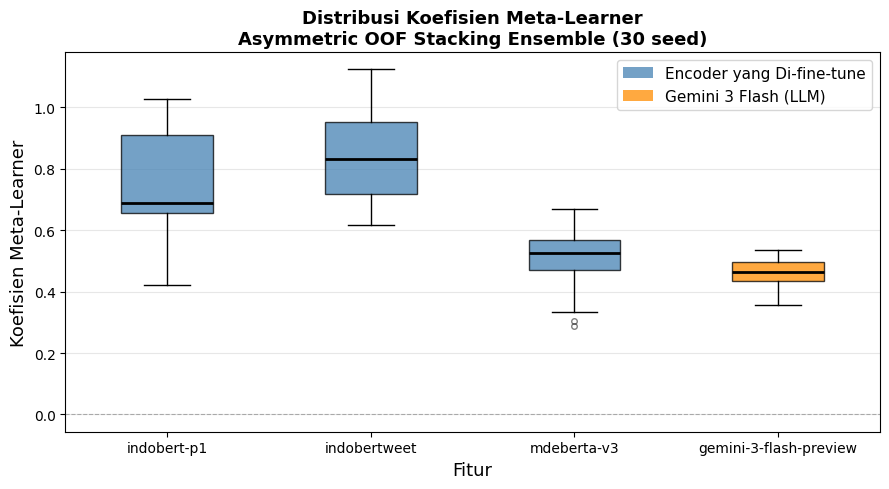

18:14:23 [INFO] Saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_coef_boxplot.png


In [9]:
coef_matrix = np.array(coef_store)   # (30, 4)

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    coef_matrix,
    labels=FEATURE_NAMES,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)

# Color encoders blue, LLM orange
colors = ["steelblue"] * len(ENCODER_COLS) + ["darkorange"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title(
    f"Distribusi Koefisien Meta-Learner\n"
    f"Asymmetric OOF Stacking Ensemble ({N_RUNS} seed)",
    fontsize=13, fontweight="bold"
)
ax.set_ylabel("Koefisien Meta-Learner", fontsize=13)
ax.set_xlabel("Fitur", fontsize=13)
ax.grid(axis="y", alpha=0.3)

legend_handles = [
    mpatches.Patch(facecolor="steelblue",  alpha=0.75, label="Encoder yang Di-fine-tune"),
    mpatches.Patch(facecolor="darkorange", alpha=0.75, label="Gemini 3 Flash (LLM)"),
]
ax.legend(handles=legend_handles, fontsize=11)
plt.tight_layout()

boxplot_path = OUT_DIR / "phase_c_coef_boxplot.png"
plt.savefig(boxplot_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: %s", boxplot_path)

## 9. Visualization B — Reliability Diagrams (Calibration Map)

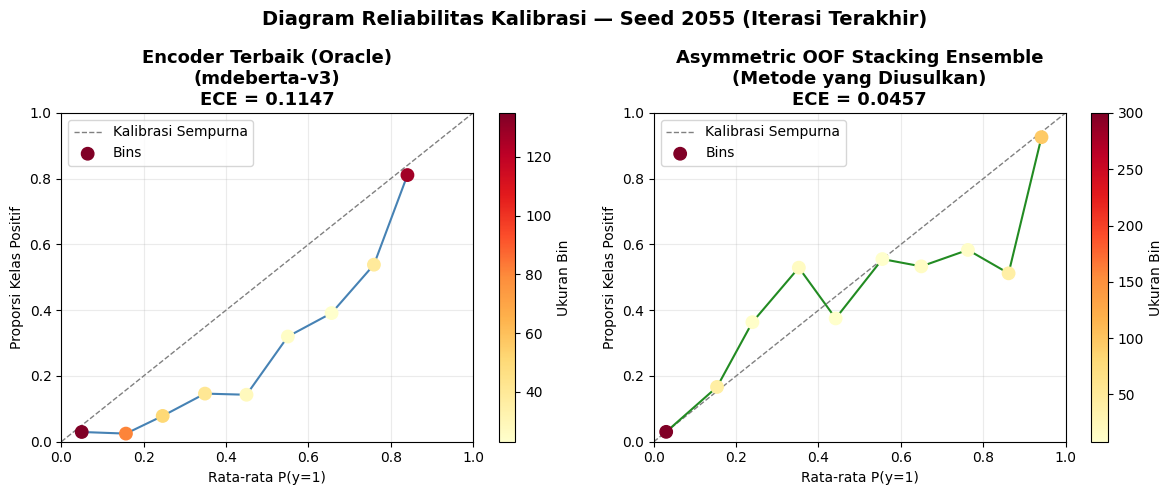

18:14:23 [INFO] Saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_reliability_diagrams.png


In [10]:
def reliability_diagram(ax, y_true, y_prob_pos, title, color, n_bins=ECE_BINS):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs, bin_sizes = [], [], []

    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob_pos >= low) & (y_prob_pos <= high) if high == 1.0 \
               else (y_prob_pos >= low) & (y_prob_pos < high)
        if mask.sum() > 0:
            bin_accs.append(y_true[mask].mean())
            bin_confs.append(y_prob_pos[mask].mean())
            bin_sizes.append(mask.sum())

    ece_val = expected_calibration_error_positive_class(y_true, y_prob_pos)

    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Kalibrasi Sempurna")
    if bin_confs:
        sc = ax.scatter(bin_confs, bin_accs, c=bin_sizes,
                        cmap="YlOrRd", s=80, zorder=5, label="Bins")
        ax.plot(bin_confs, bin_accs, "-", color=color, linewidth=1.5)
        plt.colorbar(sc, ax=ax, label="Ukuran Bin")

    ax.set_title(f"{title}\nECE = {ece_val:.4f}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Rata-rata P(y=1)")
    ax.set_ylabel("Proporsi Kelas Positif")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Diagram Reliabilitas Kalibrasi — Seed {SEEDS[-1]} (Iterasi Terakhir)",
    fontsize=14, fontweight="bold"
)

reliability_diagram(
    axes[0],
    y_test,
    last_seed_data["best_enc_conf"],
    title=f"Encoder Terbaik (Oracle)\n({last_seed_data['best_enc_name']})",
    color="steelblue",
)
reliability_diagram(
    axes[1],
    y_test,
    last_seed_data["asym_conf"],
    title="Asymmetric OOF Stacking Ensemble\n(Metode yang Diusulkan)",
    color="forestgreen",
)

plt.tight_layout()
rel_path = OUT_DIR / "phase_c_reliability_diagrams.png"
plt.savefig(rel_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: %s", rel_path)

## 10. Visualization C — Per-Metric Comparison Across Seeds

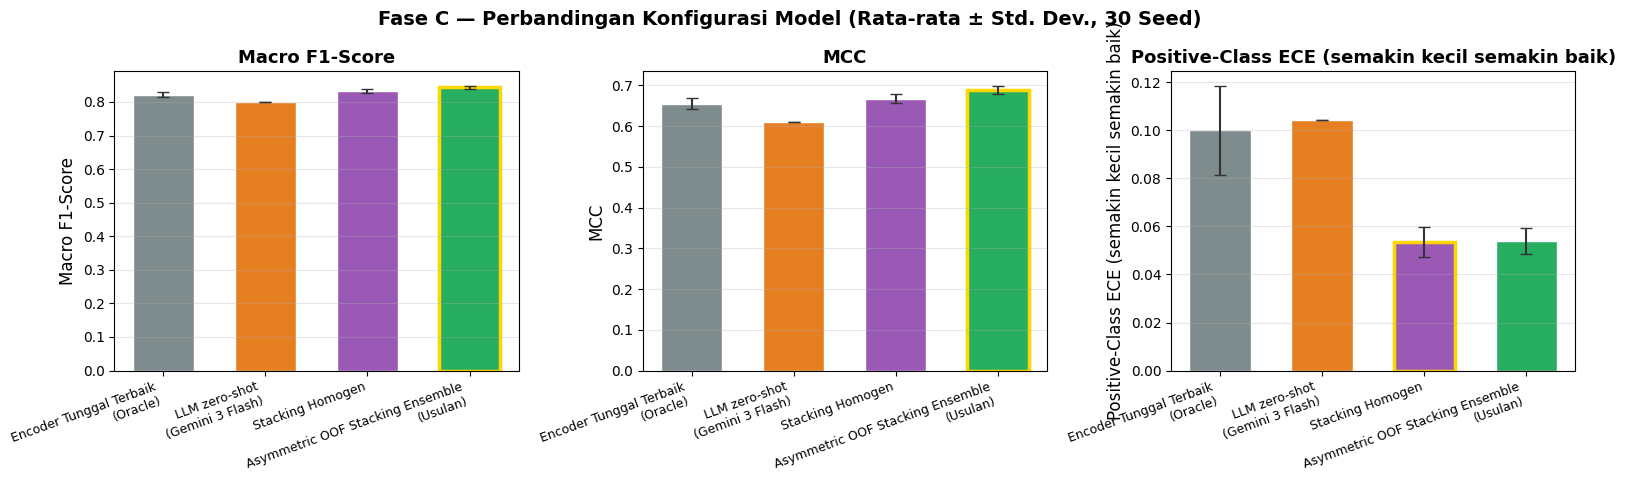

18:14:24 [INFO] Saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_comparison_chart.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fase C — Perbandingan Konfigurasi Model (Rata-rata ± Std. Dev., 30 Seed)",
             fontsize=14, fontweight="bold")

cfg_labels = [name.replace(" (", "\n(") for name, _ in configs]
bar_colors = ["#7f8c8d", "#e67e22", "#9b59b6", "#27ae60"]

metric_specs = [
    ("macro_f1", "Macro F1-Score",           True),
    ("mcc",      "MCC",                      True),
    ("ece",      "Positive-Class ECE (semakin kecil semakin baik)", False),
]

for ax, (key, ylabel, higher_better) in zip(axes, metric_specs):
    means = [agg[f"{key}_mean"] for _, agg in configs]
    stds  = [agg[f"{key}_std"]  for _, agg in configs]
    x     = np.arange(len(configs))

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=bar_colors,
                  edgecolor="white", width=0.6,
                  error_kw={"linewidth": 1.5, "ecolor": "#333"})

    # Gold border on best (skip oracle for fairness)
    compare_means = [(i, m) for i, m in enumerate(means) if i > 0]
    best_i = max(compare_means, key=lambda t: t[1] if higher_better else -t[1])[0]
    bars[best_i].set_edgecolor("gold")
    bars[best_i].set_linewidth(2.5)

    ax.set_xticks(x)
    ax.set_xticklabels(cfg_labels, fontsize=9, rotation=20, ha="right")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(ylabel, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
cmp_path = OUT_DIR / "phase_c_comparison_chart.png"
plt.savefig(cmp_path, dpi=150, bbox_inches="tight")
plt.show()
logger.info("Saved: %s", cmp_path)

## 11. Save Full JSON Summary

In [12]:
coef_matrix_np = np.array(coef_store)   # (30, 4)

summary = {
    "phase":       "C — Asymmetric Ensemble Synthesis (LogisticRegression)",
    "meta_learner": "LogisticRegression (L2, lbfgs)",
    "seeds":       [int(s) for s in SEEDS],
    "n_runs":      N_RUNS,
    "cv_folds":    CV_FOLDS,
    "C_grid":      C_GRID,
    "ece_definition": "positive-class ECE: bins by P(y=1), compares observed class-1 rate",
    "ece_bins": ECE_BINS,
    "ece_implementation_version": ECE_IMPLEMENTATION_VERSION,
    "paired_ttest": ttest_results,
    "configurations": {
        name: {
            k: round(float(v), 6) for k, v in agg.items()
        }
        for name, agg in configs
    },
    "ridge_coef_mean": {
        name: round(float(v), 6)
        for name, v in zip(FEATURE_NAMES, coef_matrix_np.mean(axis=0))
    },
    "ridge_coef_std": {
        name: round(float(v), 6)
        for name, v in zip(FEATURE_NAMES, coef_matrix_np.std(axis=0, ddof=1))
    },
    "output_files": {
        "raw_results":       str(OUT_DIR / "phase_c_raw_results.csv"),
        "summary_table":     str(OUT_DIR / "phase_c_summary_table.csv"),
        "coef_boxplot":      str(OUT_DIR / "phase_c_coef_boxplot.png"),
        "reliability":       str(OUT_DIR / "phase_c_reliability_diagrams.png"),
        "comparison_chart":  str(OUT_DIR / "phase_c_comparison_chart.png"),
    }
}

summary_path = OUT_DIR / "phase_c_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(json.dumps(summary, indent=2, ensure_ascii=False))
logger.info("Summary saved: %s", summary_path)

18:14:24 [INFO] Summary saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_summary.json


{
  "phase": "C — Asymmetric Ensemble Synthesis (LogisticRegression)",
  "meta_learner": "LogisticRegression (L2, lbfgs)",
  "seeds": [
    2026,
    2027,
    2028,
    2029,
    2030,
    2031,
    2032,
    2033,
    2034,
    2035,
    2036,
    2037,
    2038,
    2039,
    2040,
    2041,
    2042,
    2043,
    2044,
    2045,
    2046,
    2047,
    2048,
    2049,
    2050,
    2051,
    2052,
    2053,
    2054,
    2055
  ],
  "n_runs": 30,
  "cv_folds": 5,
  "C_grid": [
    1e-05,
    0.0001,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0,
    20.0,
    50.0,
    100.0
  ],
  "ece_definition": "positive-class ECE: bins by P(y=1), compares observed class-1 rate",
  "ece_bins": 10,
  "ece_implementation_version": "positive_class_ece_v2_2026-07-26",
  "paired_ttest": [
    {
      "metric": "Macro F1",
      "delta": 0.01047,
      "t_stat": 7.682679,
      "p_one_tailed": 0.0,
      "significant": true
    },
    {
      "metri

## 12. Output Files Inventory

In [13]:
output_files = [
    (OUT_DIR / "phase_c_raw_results.csv",         "Per-seed raw metrics for all configs"),
    (OUT_DIR / "phase_c_summary_table.csv",        "Thesis-ready Mean ± Std table with positive-class ECE"),
    (OUT_DIR / "phase_c_summary.json",             "Full JSON summary + t-test + coef stats"),
    (OUT_DIR / "phase_c_coef_boxplot.png",         "Ridge coefficient boxplot (30 seeds)"),
    (OUT_DIR / "phase_c_reliability_diagrams.png", "Positive-class reliability diagrams (best enc vs. proposed)"),
    (OUT_DIR / "phase_c_comparison_chart.png",     "F1 / MCC / ECE bar comparison"),
]

print(f"\n📁 Output Directory: {OUT_DIR}")
print("─" * 72)
for fpath, desc in output_files:
    p      = Path(fpath)
    exists = p.is_file()
    size   = f"{p.stat().st_size / 1024:.1f} KB" if exists else "NOT FOUND"
    status = "✅" if exists else "❌"
    print(f"  {status}  {p.name:<50}  {size:<12}  {desc}")
print("─" * 72)
print("\n✅ Phase C complete.")


📁 Output Directory: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2
────────────────────────────────────────────────────────────────────────
  ✅  phase_c_raw_results.csv                             6.0 KB        Per-seed raw metrics for all configs
  ✅  phase_c_summary_table.csv                           0.4 KB        Thesis-ready Mean ± Std table with positive-class ECE
  ✅  phase_c_summary.json                                3.3 KB        Full JSON summary + t-test + coef stats
  ✅  phase_c_coef_boxplot.png                            60.2 KB       Ridge coefficient boxplot (30 seeds)
  ✅  phase_c_reliability_diagrams.png                    132.4 KB      Positive-class reliability diagrams (best enc vs. proposed)
  ✅  phase_c_comparison_chart.png                        131.2 KB      F1 / MCC / ECE bar comparison
────────────────────────────────────────────────────────────────────────

✅ Phase C complete.


## 13. Ablation Study — Leave-One-Feature-Out

Reuses the already-loaded per-seed encoder CSVs and the static LLM `.npy` arrays.
No retraining of encoders, no new LLM calls — only refits the cheap Logistic Regression
meta-learner on different column subsets, per seed, same as the main loop.


In [14]:
# Recheck the ECE implementation before the additional 30-seed ablation loop.
assert_positive_class_ece_runtime()

# ── Ablation configs: which columns (by name) go into the meta-learner ────────
ABLATION_CONFIGS = {
    "Full (3 encoders + LLM)":        ["indobert-p1", "indobertweet", "mdeberta-v3", "LLM"],
    "minus indobert-p1":              ["indobertweet", "mdeberta-v3", "LLM"],
    "minus indobertweet":             ["indobert-p1", "mdeberta-v3", "LLM"],
    "minus mdeberta-v3":              ["indobert-p1", "indobertweet", "LLM"],
    "minus LLM (= Homogeneous)":      ["indobert-p1", "indobertweet", "mdeberta-v3"],
}

def build_columns(oof_df, test_df, llm_tr, llm_te, wanted):
    """Assemble X_train / X_test from a list of feature names."""
    enc_names = [c for c in wanted if c != "LLM"]
    X_tr = oof_df[enc_names].values.astype(np.float32)
    X_te = test_df[enc_names].values.astype(np.float32)
    if "LLM" in wanted:
        X_tr = np.hstack([X_tr, llm_tr.reshape(-1, 1)])
        X_te = np.hstack([X_te, llm_te.reshape(-1, 1)])
    return X_tr, X_te

ablation_records = []

logger.info("Starting ablation loop (%d configs x %d seeds)...",
            len(ABLATION_CONFIGS), N_RUNS)

for seed in SEEDS:
    oof_df  = pd.read_csv(Path(OOF_TRAIN_TEMPLATE.format(seed=seed)))
    test_df = pd.read_csv(Path(PROBS_TEST_TEMPLATE.format(seed=seed)))

    for cfg_name, cols in ABLATION_CONFIGS.items():
        X_tr, X_te = build_columns(oof_df, test_df, llm_train_full, llm_test_flat, cols)
        best_C = tune_C(X_tr, y_train_full, seed=seed)
        pred, conf, _ = fit_predict_logistic(X_tr, y_train_full, X_te, best_C, seed)
        m = compute_metrics(y_test, pred, conf)
        ablation_records.append({
            "seed": seed, "config": cfg_name,
            "macro_f1": m["macro_f1"], "mcc": m["mcc"], "ece": m["ece"],
        })

logger.info("Ablation loop complete.")

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_csv(OUT_DIR / "phase_c_ablation_raw.csv", index=False)

ablation_summary = (
    ablation_df.groupby("config")[["macro_f1", "mcc", "ece"]]
    .agg(["mean", "std"])
)
ablation_summary.to_csv(OUT_DIR / "phase_c_ablation_summary.csv")
print(tabulate(ablation_summary.round(4), headers="keys", tablefmt="github"))


18:14:24 [INFO] Starting ablation loop (5 configs x 30 seeds)...


ECE PREFLIGHT PASSED
  Implementation : positive_class_ece_v2_2026-07-26
  Definition     : bins by P(y=1); compares observed positive rate
  Sanity ECE     : 2.7755575615628914e-17
  compute_metrics references: ('np', 'asarray', 'int32', 'ravel', 'float', 'shape', 'ValueError', 'f1_score', 'matthews_corrcoef', 'expected_calibration_error_positive_class', 'ECE_BINS')


18:15:12 [INFO] Ablation loop complete.


| config                    |   ('macro_f1', 'mean') |   ('macro_f1', 'std') |   ('mcc', 'mean') |   ('mcc', 'std') |   ('ece', 'mean') |   ('ece', 'std') |
|---------------------------|------------------------|-----------------------|-------------------|------------------|-------------------|------------------|
| Full (3 encoders + LLM)   |                 0.8435 |                0.0052 |            0.6893 |           0.0104 |            0.0538 |           0.0053 |
| minus LLM (= Homogeneous) |                 0.833  |                0.0059 |            0.6679 |           0.0115 |            0.0535 |           0.0061 |
| minus indobert-p1         |                 0.8442 |                0.0059 |            0.6917 |           0.0113 |            0.0549 |           0.0046 |
| minus indobertweet        |                 0.8435 |                0.0072 |            0.6895 |           0.0152 |            0.0513 |           0.0049 |
| minus mdeberta-v3         |                 0.8415 |    

In [15]:
# ── Paired t-test: Full model vs. each ablated variant (same 30 seeds) ────────
full_scores = ablation_df[ablation_df.config == "Full (3 encoders + LLM)"] \
    .sort_values("seed").reset_index(drop=True)

ablation_ttests = []
for cfg_name in ABLATION_CONFIGS:
    if cfg_name == "Full (3 encoders + LLM)":
        continue
    variant_scores = ablation_df[ablation_df.config == cfg_name] \
        .sort_values("seed").reset_index(drop=True)
    for metric in ["macro_f1", "mcc"]:
        res = paired_ttest_one_tailed(
            full_scores[metric].values, variant_scores[metric].values,
            label=f"Full vs. {cfg_name} ({metric})"
        )
        ablation_ttests.append(res)

pd.DataFrame(ablation_ttests).to_csv(OUT_DIR / "phase_c_ablation_ttests.csv", index=False)


  Full vs. minus indobert-p1 (macro_f1)
    Δ mean     : -0.0007
    t-statistic: -0.5600
    p (1-tail) : 0.710109
    Significant: ❌ NO (α=0.05)
  Full vs. minus indobert-p1 (mcc)
    Δ mean     : -0.0024
    t-statistic: -0.9940
    p (1-tail) : 0.835777
    Significant: ❌ NO (α=0.05)
  Full vs. minus indobertweet (macro_f1)
    Δ mean     : +0.0000
    t-statistic: 0.0245
    p (1-tail) : 0.490303
    Significant: ❌ NO (α=0.05)
  Full vs. minus indobertweet (mcc)
    Δ mean     : -0.0002
    t-statistic: -0.0576
    p (1-tail) : 0.522770
    Significant: ❌ NO (α=0.05)
  Full vs. minus mdeberta-v3 (macro_f1)
    Δ mean     : +0.0020
    t-statistic: 1.9548
    p (1-tail) : 0.030156
    Significant: ✅ YES (α=0.05)
  Full vs. minus mdeberta-v3 (mcc)
    Δ mean     : +0.0046
    t-statistic: 2.2812
    p (1-tail) : 0.015031
    Significant: ✅ YES (α=0.05)
  Full vs. minus LLM (= Homogeneous) (macro_f1)
    Δ mean     : +0.0105
    t-statistic: 7.6827
    p (1-tail) : 0.000000
    Signi

## 14. Error Analysis Export

Saves per-sample predictions (all 30 seeds, full asymmetric model + homogeneous
model) joined with the original test text, so misclassified cases can be inspected
and categorized without touching the encoders or LLM again.

**Check first:** confirm `TEST_LABELS_CSV` actually has a text column (printed below).
If the column has a different name than `text`, edit `TEXT_COL` accordingly.


In [16]:
print("Columns in datd_test.csv:", _test_df_check.columns.tolist())

# ── UPDATE if the text column has a different name ─────────────────────────
TEXT_COL = "text"   # ← change this if the printed column list above shows a different name
assert TEXT_COL in _test_df_check.columns, \
    f"'{TEXT_COL}' not found in datd_test.csv — set TEXT_COL to the correct column name."

per_sample_records = []

logger.info("Building per-sample prediction table across all %d seeds...", N_RUNS)

for seed in SEEDS:
    oof_df  = pd.read_csv(Path(OOF_TRAIN_TEMPLATE.format(seed=seed)))
    test_df = pd.read_csv(Path(PROBS_TEST_TEMPLATE.format(seed=seed)))

    enc_train = oof_df[ENCODER_COLS].values.astype(np.float32)
    enc_test  = test_df[ENCODER_COLS].values.astype(np.float32)
    X_train_asym = np.hstack([enc_train, llm_train_full.reshape(-1, 1)])
    X_test_asym  = np.hstack([enc_test,  llm_test_flat.reshape(-1, 1)])
    X_train_homo = enc_train
    X_test_homo  = enc_test

    best_C_asym = tune_C(X_train_asym, y_train_full, seed=seed)
    best_C_homo = tune_C(X_train_homo, y_train_full, seed=seed)

    pred_asym, conf_asym, _ = fit_predict_logistic(X_train_asym, y_train_full, X_test_asym, best_C_asym, seed)
    pred_homo, conf_homo, _ = fit_predict_logistic(X_train_homo, y_train_full, X_test_homo, best_C_homo, seed)

    seed_df = pd.DataFrame({
        "seed":         seed,
        "row_id":       np.arange(len(y_test)),
        "text":         _test_df_check[TEXT_COL].values,
        "y_true":       y_test,
        "pred_asym":    pred_asym,
        "conf_asym":    conf_asym,
        "pred_homo":    pred_homo,
        "conf_homo":    conf_homo,
    })
    per_sample_records.append(seed_df)

per_sample_df = pd.concat(per_sample_records, ignore_index=True)
per_sample_df.to_csv(OUT_DIR / "phase_c_error_analysis_all_seeds.csv", index=False)
logger.info("Saved: %s (%d rows)", OUT_DIR / "phase_c_error_analysis_all_seeds.csv", len(per_sample_df))

# ── Majority-vote view: one row per test sample, aggregated over 30 seeds ─────
agg_view = per_sample_df.groupby(["row_id", "text", "y_true"]).agg(
    asym_majority_pred = ("pred_asym", lambda s: int(s.mean() >= 0.5)),
    asym_mean_conf      = ("conf_asym", "mean"),
    asym_error_rate      = ("pred_asym", lambda s: (s != s.name).mean() if False else None),  # placeholder, fixed below
    homo_majority_pred  = ("pred_homo", lambda s: int(s.mean() >= 0.5)),
    homo_mean_conf       = ("conf_homo", "mean"),
).reset_index()

# error_rate = fraction of the 30 seeds where the model got this sample wrong
err_rate_asym = per_sample_df.groupby("row_id").apply(lambda g: (g.pred_asym != g.y_true).mean())
err_rate_homo = per_sample_df.groupby("row_id").apply(lambda g: (g.pred_homo != g.y_true).mean())
agg_view["asym_error_rate"] = agg_view["row_id"].map(err_rate_asym)
agg_view["homo_error_rate"] = agg_view["row_id"].map(err_rate_homo)

agg_view.to_csv(OUT_DIR / "phase_c_error_analysis_aggregated.csv", index=False)
logger.info("Saved: %s (%d rows)", OUT_DIR / "phase_c_error_analysis_aggregated.csv", len(agg_view))

# ── Quick-look: consistently-wrong False Negatives / False Positives ──────────
consistent_fn = agg_view[(agg_view.y_true == 1) & (agg_view.asym_error_rate >= 0.8)]
consistent_fp = agg_view[(agg_view.y_true == 0) & (agg_view.asym_error_rate >= 0.8)]
print(f"\nSamples misclassified as False Negative in ≥80% of seeds: {len(consistent_fn)}")
print(f"Samples misclassified as False Positive in ≥80% of seeds: {len(consistent_fp)}")

# ── Cases the LLM integration fixed vs. broke, relative to homogeneous stacking ─
fixed_by_llm  = agg_view[(agg_view.homo_error_rate >= 0.8) & (agg_view.asym_error_rate <= 0.2)]
broken_by_llm = agg_view[(agg_view.homo_error_rate <= 0.2) & (agg_view.asym_error_rate >= 0.8)]
fixed_by_llm.to_csv(OUT_DIR / "phase_c_fixed_by_llm.csv", index=False)
broken_by_llm.to_csv(OUT_DIR / "phase_c_broken_by_llm.csv", index=False)
print(f"Cases fixed by LLM integration   : {len(fixed_by_llm)}  -> phase_c_fixed_by_llm.csv")
print(f"Cases broken by LLM integration  : {len(broken_by_llm)}  -> phase_c_broken_by_llm.csv")


18:15:12 [INFO] Building per-sample prediction table across all 30 seeds...


Columns in datd_test.csv: ['text', 'label']


18:15:31 [INFO] Saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_error_analysis_all_seeds.csv (16500 rows)
18:15:31 [INFO] Saved: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_error_analysis_aggregated.csv (550 rows)



Samples misclassified as False Negative in ≥80% of seeds: 25
Samples misclassified as False Positive in ≥80% of seeds: 38
Cases fixed by LLM integration   : 0  -> phase_c_fixed_by_llm.csv
Cases broken by LLM integration  : 1  -> phase_c_broken_by_llm.csv


## 15. Final ECE Implementation Verification

This final check confirms that the completed notebook still references the corrected positive-class ECE implementation.


In [17]:
assert_positive_class_ece_runtime()
print("\nFinal verification complete.")
print("Summary file:", OUT_DIR / "phase_c_summary_table.csv")
print("ECE version :", ECE_IMPLEMENTATION_VERSION)


ECE PREFLIGHT PASSED
  Implementation : positive_class_ece_v2_2026-07-26
  Definition     : bins by P(y=1); compares observed positive rate
  Sanity ECE     : 2.7755575615628914e-17
  compute_metrics references: ('np', 'asarray', 'int32', 'ravel', 'float', 'shape', 'ValueError', 'f1_score', 'matthews_corrcoef', 'expected_calibration_error_positive_class', 'ECE_BINS')

Final verification complete.
Summary file: C:\Users\KOMPUTER\VSCode Projects\IndoEnsemble\Final Thesis Execution\Phase C Results\Ablation and Error\ECE Positive Class V2\phase_c_summary_table.csv
ECE version : positive_class_ece_v2_2026-07-26
